Financial data ingestion

In [1]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
ticker_symbol = "RELIANCE.NS"
# ticker_symbol = "BHARTIARTL.NS"
# ticker_symbol = "AAPL"

if os.path.exists("stock_data.csv"):
    df = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)
else:
    print("Downloading data")
    df = yf.download(ticker_symbol, period="5y")
    df.columns = df.columns.get_level_values(0)
    df.to_csv("stock_data.csv")

In [3]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-03-19,944.043884,950.323919,899.063525,902.781664,41787429
2021-03-22,935.156555,940.416353,921.916389,939.056098,18572478
2021-03-23,946.537781,956.603959,932.254709,934.952612,17421165
2021-03-24,928.309875,943.023698,925.181222,943.023698,16822814
2021-03-25,902.985657,931.347788,900.061015,931.347788,22001648


In [4]:
df = df.sort_index()
df['SMA'] = df['Close'].rolling(window=50).mean()
df.head()

,Close,High,Low,Open,Volume,SMA
Date,,,,,,
2021-03-19,944.043884,950.323919,899.063525,902.781664,41787429,NaN
2021-03-22,935.156555,940.416353,921.916389,939.056098,18572478,NaN
2021-03-23,946.537781,956.603959,932.254709,934.952612,17421165,NaN
2021-03-24,928.309875,943.023698,925.181222,943.023698,16822814,NaN
2021-03-25,902.985657,931.347788,900.061015,931.347788,22001648,NaN


In [5]:
df.dropna(inplace=True)

df['Error'] = df['Close'] - df['SMA']
df['Percentage'] = df['Error'].abs() / df['Close']
result = df['Percentage'].mean() * 100
result, df.head(5)

(np.float64(4.279756833004096),
                   Close         High         Low         Open    Volume  \
 Date                                                                      
 2021-06-03  1001.924377  1020.220331  995.780410  1007.070776  23974257   
 2021-06-04   993.241211  1005.007723  990.407241  1004.259562  14468646   
 2021-06-07  1009.972656  1016.592769  990.747199   998.455552  16336573   
 2021-06-08  1004.168823  1009.859372  996.709877  1009.610025   9674735   
 2021-06-09   986.213013  1007.070802  978.481991  1006.163965  11409161   
 
                    SMA       Error  Percentage  
 Date                                            
 2021-06-03  903.175679   98.748699    0.098559  
 2021-06-04  904.159625   89.081586    0.089688  
 2021-06-07  905.655947  104.316709    0.103287  
 2021-06-08  906.808568   97.360255    0.096956  
 2021-06-09  907.966631   78.246382    0.079340  )

News Feed Ingestion

In [6]:
import feedparser
import pandas as pd
from transformers import pipeline

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
if os.path.exists('news.csv'):
    print("Old News Found")
    news_df = pd.read_csv("news.csv")
else:
    link = "https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en"
    feed = feedparser.parse(link)
    news = []
    for item in feed.entries[:5000]:
        # print(item)
        date = item.published
        headline = item.title
        news.append({'published': pd.to_datetime(date).date(),
                    'headline': headline})
    news_df = pd.DataFrame(news)
    news_df.to_csv('news.csv', index=False)
    # news_df

Old News Found


Sentiment Analysis

In [29]:
sentiment_analyser = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Device set to use cpu


In [30]:
results = sentiment_analyser(news_df['headline'].tolist())

news_df['label'] = [result['label'] for result in results]
news_df['score'] = [result['score'] for result in results]
news_df.head()

,published,headline,label,score,sentiment_value,adjusted_score
0,2026-03-16,RIL shares fall over 2% post Q1 results; analy...,negative,0.973436,-1,-0.973436
1,2026-03-19,Reliance Industries Ltd Sees High-Value Tradin...,positive,0.767924,1,0.767924
2,2026-03-19,RIL top stock pick amid Iran war; GAIL least i...,positive,0.748992,1,0.748992
3,2026-03-19,"RIL, HDFC Securities and more: Top stocks to w...",neutral,0.931816,0,0.000000
4,2026-03-17,"Stocks to watch: Reliance Industries, Tata Mot...",neutral,0.931602,0,0.000000


In [31]:
news_df['sentiment_value'] = news_df['label'].str.lower().map({'positive': 1, 'neutral': 0, 'negative': -1})
news_df['adjusted_score'] = news_df['score'] * news_df['sentiment_value']
# news_df['daily_sentiment'] = news_df['adjusted_score'].groupby(news_df['published']).mean()
news_df.head()

,published,headline,label,score,sentiment_value,adjusted_score
0,2026-03-16,RIL shares fall over 2% post Q1 results; analy...,negative,0.973436,-1,-0.973436
1,2026-03-19,Reliance Industries Ltd Sees High-Value Tradin...,positive,0.767924,1,0.767924
2,2026-03-19,RIL top stock pick amid Iran war; GAIL least i...,positive,0.748992,1,0.748992
3,2026-03-19,"RIL, HDFC Securities and more: Top stocks to w...",neutral,0.931816,0,0.000000
4,2026-03-17,"Stocks to watch: Reliance Industries, Tata Mot...",neutral,0.931602,0,0.000000


In [32]:
daily_sentiment_df = news_df.groupby('published')['adjusted_score'].mean().reset_index()
daily_sentiment_df.head(10)

,published,adjusted_score
0,2025-08-19,0.916222
1,2025-10-19,0.938015
2,2025-11-20,0.930381
3,2025-11-25,0.915676
4,2025-11-28,0.617980
5,2025-12-02,-0.962348
6,2025-12-03,0.000000
7,2025-12-31,0.000000
8,2026-01-01,0.743345
9,2026-01-04,0.000000


Fusion Model - Data Preprocessing

In [15]:
df = df.reset_index()
df.head()

,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage
0,2021-06-03,1001.924377,1020.220331,995.780410,1007.070776,23974257,903.175679,98.748699,0.098559
1,2021-06-04,993.241211,1005.007723,990.407241,1004.259562,14468646,904.159625,89.081586,0.089688
2,2021-06-07,1009.972656,1016.592769,990.747199,998.455552,16336573,905.655947,104.316709,0.103287
3,2021-06-08,1004.168823,1009.859372,996.709877,1009.610025,9674735,906.808568,97.360255,0.096956
4,2021-06-09,986.213013,1007.070802,978.481991,1006.163965,11409161,907.966631,78.246382,0.079340


In [16]:
df['Date'] = pd.to_datetime(df['Date'])
daily_sentiment_df['published'] = pd.to_datetime(daily_sentiment_df['published'])
master_df = pd.merge(df, daily_sentiment_df, how='left', left_on='Date', right_on='published')
master_df['adjusted_score'] = master_df['adjusted_score'].fillna(0)
master_df.tail(15)

,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,published,adjusted_score
1173,2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858,1467.620002,-60.819954,0.043233,2026-02-26,0.000000
1174,2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440,1464.610002,-70.709978,0.050728,NaT,0.000000
1175,2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722,1460.882002,-102.882002,0.075760,NaT,0.000000
1176,2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007,1456.480002,-111.480002,0.082885,NaT,0.000000
1177,2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532,1452.760002,-63.359978,0.045602,2026-03-05,0.259737
1178,2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311971,1449.442004,-44.641956,0.031778,2026-03-06,0.699898
1179,2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822,1446.758005,-22.758005,0.015982,2026-03-09,0.672132
1180,2026-03-10,1408.800049,1431.500000,1400.599976,1430.599976,18071259,1443.750007,-34.949958,0.024808,NaT,0.000000
1181,2026-03-11,1390.199951,1434.000000,1383.599976,1424.900024,21848087,1440.642007,-50.442056,0.036284,2026-03-11,-0.094962
1182,2026-03-12,1392.199951,1410.900024,1381.099976,1390.000000,20939959,1437.690005,-45.490054,0.032675,2026-03-12,0.000000


In [17]:
master_df['Target'] = master_df['Close'].shift(-1)
tomorrow_features = master_df.iloc[-1:]
master_df = master_df.dropna()
master_df.tail(15)

,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,published,adjusted_score,Target
1156,2026-02-03,1437.099976,1489.500000,1430.199951,1473.900024,25456171,1505.868000,-68.768025,0.047852,2026-02-03,0.000000,1456.800049
1158,2026-02-05,1443.400024,1461.500000,1439.500000,1457.000000,11763658,1502.360002,-58.959978,0.040848,2026-02-05,-0.822527,1450.800049
1169,2026-02-20,1419.400024,1427.400024,1406.099976,1409.500000,8177670,1478.378000,-58.977976,0.041551,2026-02-20,-0.470790,1428.000000
1171,2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409,1473.484001,-44.683953,0.031274,2026-02-24,0.000000,1398.500000
1172,2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792,1470.330002,-71.830002,0.051362,2026-02-25,0.000000,1406.800049
1173,2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858,1467.620002,-60.819954,0.043233,2026-02-26,0.000000,1393.900024
1177,2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532,1452.760002,-63.359978,0.045602,2026-03-05,0.259737,1404.800049
1178,2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311971,1449.442004,-44.641956,0.031778,2026-03-06,0.699898,1424.000000
1179,2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822,1446.758005,-22.758005,0.015982,2026-03-09,0.672132,1408.800049
1181,2026-03-11,1390.199951,1434.000000,1383.599976,1424.900024,21848087,1440.642007,-50.442056,0.036284,2026-03-11,-0.094962,1392.199951


In [18]:
features = ['Volume', 'SMA', 'Error', 'adjusted_score']
X = master_df[features]
y = master_df['Target']
X.tail(10), y.tail(10)

(        Volume          SMA      Error  adjusted_score
 1173  16683858  1467.620002 -60.819954        0.000000
 1177  25957532  1452.760002 -63.359978        0.259737
 1178  19311971  1449.442004 -44.641956        0.699898
 1179  24870822  1446.758005 -22.758005        0.672132
 1181  21848087  1440.642007 -50.442056       -0.094962
 1182  20939959  1437.690005 -45.490054        0.000000
 1183  17265090  1433.896003 -53.196052        0.000000
 1184  22837802  1430.286003 -35.186028       -0.534805
 1185  19007744  1426.392002 -28.792026        0.238427
 1186   9559327  1422.992002 -14.892026       -0.291446,
 1173    1393.900024
 1177    1404.800049
 1178    1424.000000
 1179    1408.800049
 1181    1392.199951
 1182    1380.699951
 1183    1395.099976
 1184    1397.599976
 1185    1408.099976
 1186    1391.199951
 Name: Target, dtype: float64)

In [19]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(X)

(25, 7, 32)

In [20]:
X.head()

,Volume,SMA,Error,adjusted_score
1042,14384719,1440.358884,-20.258909,0.916222
1105,18171724,1432.506011,116.593965,0.930381
1108,15033482,1442.220010,97.479941,0.915676
1111,8959508,1452.244009,115.255991,0.617980
1113,11389150,1457.916008,88.384041,-0.962348


Fusion Model - Model

In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [22]:
model = XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
predictions = model.predict(X_test)
predictions

array([1418.071 , 1401.7693, 1401.7693, 1407.6929, 1401.7695, 1407.6929,
       1404.5815], dtype=float32)

In [24]:
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 10.065830775669642


In [25]:
live_features = tomorrow_features[['Volume', 'SMA', 'Error', 'adjusted_score']]

In [26]:
tomorrow_prediction = model.predict(live_features)
print(f"Predicted Reliance Close Price for Tomorrow: ₹{tomorrow_prediction[0]:.2f}")

Predicted Reliance Close Price for Tomorrow: ₹1408.69


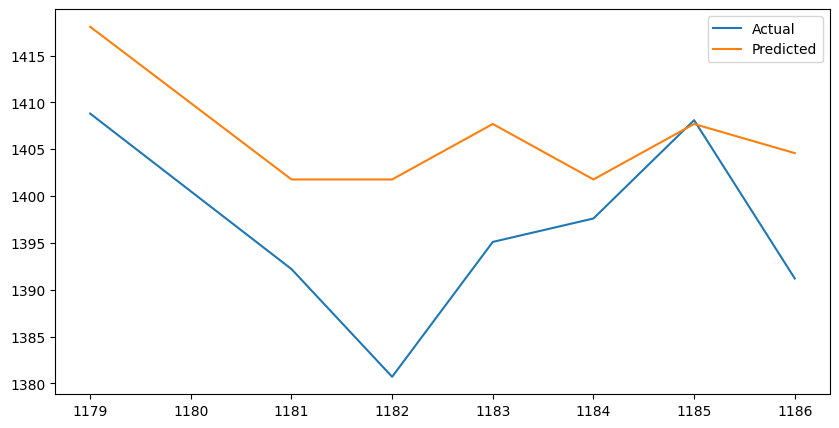

In [27]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, predictions, label='Predicted')

plt.legend()
plt.show()

Live Dataset Prediction

In [41]:
live_df = yf.Ticker("RELIANCE.NS").history(period="60d")
live_df.head(6)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-12-23 00:00:00+05:30,1580.900024,1580.900024,1568.099976,1570.699951,7506564,0.0,0.0
2025-12-24 00:00:00+05:30,1572.699951,1575.699951,1553.599976,1558.199951,8815745,0.0,0.0
2025-12-26 00:00:00+05:30,1554.699951,1561.000000,1554.300049,1559.199951,2311495,0.0,0.0
2025-12-29 00:00:00+05:30,1554.900024,1558.099976,1543.599976,1545.599976,5972105,0.0,0.0
2025-12-30 00:00:00+05:30,1547.000000,1553.599976,1537.800049,1539.800049,8815884,0.0,0.0
2025-12-31 00:00:00+05:30,1541.000000,1577.000000,1541.000000,1570.400024,5771830,0.0,0.0


In [43]:
live_df['SMA'] = live_df['Close'].rolling(window=50).mean()
live_df['Error'] = live_df['Close'] - live_df['SMA']

In [44]:
live_df.dropna(inplace=True)
live_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA,Error
Date,,,,,,,,,
2026-03-05 00:00:00+05:30,1353.099976,1399.000000,1353.099976,1389.400024,25957532,0.0,0.0,1452.760002,-63.359978
2026-03-06 00:00:00+05:30,1396.500000,1424.300049,1390.300049,1404.800049,19311971,0.0,0.0,1449.442004,-44.641956
2026-03-09 00:00:00+05:30,1375.000000,1429.400024,1370.000000,1424.000000,24870822,0.0,0.0,1446.758005,-22.758005
2026-03-10 00:00:00+05:30,1430.599976,1431.500000,1400.599976,1408.800049,18071259,0.0,0.0,1443.750007,-34.949958
2026-03-11 00:00:00+05:30,1424.900024,1434.000000,1383.599976,1390.199951,21848087,0.0,0.0,1440.642007,-50.442056


In [45]:
today_volume = live_df['Volume'].iloc[-1]
today_sma = live_df['SMA'].iloc[-1]
today_error = live_df['Error'].iloc[-1]
today_close = live_df['Close'].iloc[-1]

In [49]:
link = "https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en"
feed = feedparser.parse(link)
today_news = []
for item in feed.entries[:]:
    date = item.published
    headline = item.title
    today_news.append({'published': pd.to_datetime(date).date(),
                'headline': headline})
today_news_df = pd.DataFrame(today_news)
today_result = sentiment_analyser(today_news_df['headline'].tolist())

today_news_df['label'] = [result['label'] for result in today_result]
today_news_df['score'] = [result['score'] for result in today_result]
today_news_df.head()

,published,headline,label,score
0,2026-03-19,RIL shares fall over 2% post Q1 results; analy...,negative,0.973436
1,2026-03-19,Reliance Industries Ltd Sees High-Value Tradin...,positive,0.767924
2,2026-03-19,RIL top stock pick amid Iran war; GAIL least i...,positive,0.748992
3,2026-03-17,"Stocks to watch: Reliance Industries, Tata Mot...",neutral,0.931602
4,2026-03-17,"Stocks in Focus: Reliance Industries, Sun Phar...",neutral,0.939556


In [51]:
len(today_news_df)

100

In [53]:
today_news_df['sentiment_value'] = today_news_df['label'].str.lower().map({'positive': 1, 'neutral': 0, 'negative': -1})
today_news_df['adjusted_score'] = today_news_df['score'] * today_news_df['sentiment_value']
today_sentiment = today_news_df['adjusted_score'].mean()
today_sentiment

np.float64(-0.08420042604207993)

In [56]:
master_df['Target_Return'] = master_df['Close'].pct_change().shift(-1)
master_df.dropna(inplace=True)
X = master_df[['Volume', 'SMA', 'Error', 'adjusted_score']]
y = master_df['Target_Return']
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
model.fit(X_train, y_train)
print("Brain successfully upgraded to Percentage Returns")

Brain successfully upgraded to Percentage Returns


In [57]:
predicted_return = model.predict(live_features)[0]
predicted_price = today_close * (1 + predicted_return)

print("="*30)
print("REAL LIVE PREDICTION")
print("="*30)
print(f"Today's Close:   ₹{today_close:.2f}")
print(f"Predicted Move:  {predicted_return * 100:.2f}%")
print(f"Target Price:    ₹{predicted_price:.2f}")
print("="*30)

REAL LIVE PREDICTION
Today's Close:   ₹1384.80
Predicted Move:  -0.52%
Target Price:    ₹1377.55
